### Import standard libraries & Set up plotting styles

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import pandas_ta_classic as ta


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import yfinance as yf
from nsepy import get_history
from datetime import date


In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12# Set random seeds for reproducibility
np.random.seed(42)

### Data Extraction & Preprocessing

In [3]:
def download_stock_data(ticker, start_date, end_date):
    try:
        df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False)
        df.dropna(inplace=True)
        return df
    except Exception as e:
        print(f"Error downloading data for {ticker}: {e}")
        return pd.DataFrame()

### Visualize the preprocessed data 

In [7]:
ticker = ["RELIANCE.NS"]
start_date = '2020-01-01'
end_date = '2023-01-01'
df = download_stock_data(ticker, start_date, end_date)
ma_period = 10
vma_period = 7
# df["Volume"].plot()

[*********************100%***********************]  1 of 1 completed


### Create Functions to calculate Technical Indicators

In [8]:
def calculate_rsi(data, period=14):
    delta = data.diff()
    
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

def calculate_macd(data, fast=12, slow=26, signal=9):
    ema_fast = data.ewm(span=fast).mean()
    ema_slow = data.ewm(span=slow).mean()
    
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal).mean()
    histogram = macd_line - signal_line
    
    return macd_line, signal_line, histogram

def calculate_sma(data, period=ma_period):
    return data.rolling(window=period).mean()

def calculate_ema(data, period=ma_period):
    return data.ewm(span=period).mean()

def calculate_volume_sma(volume, period=vma_period):
    return volume.rolling(window=period).mean()
    

### Feature Engineering & Feature Selection
- Create Features 
- Select the most relevant features to train the model

In [11]:
def create_features(df):
    df_indicators = df.copy()
    
    # Calculate daily returns
    df_indicators['returns'] = df_indicators['Close'].pct_change()
    
    # Calculate n-period Simple Moving Average (SMA)
    df_indicators['sma'] = df_indicators['Close'].rolling(window=ma_period).mean()

    # Add RSI and MACD indicators
    df_indicators["rsi"] = calculate_rsi(df_indicators["Close"])
    macd_line, signal_line, histogram = calculate_macd(df_indicators['Close'])
    df_indicators['macd'] = macd_line
    df_indicators['macd_signal'] = signal_line
    df_indicators['macd_histogram'] = histogram

    # Add SMA and volume average indicators
    df_indicators['sma_10'] = calculate_sma(df_indicators['Close'])
    df_indicators['sma_50'] = calculate_sma(df_indicators['Close'], period=50)
    df_indicators['sma_200'] = calculate_sma(df_indicators['Close'], period=200)
    df_indicators['ema'] = calculate_ema(df_indicators['Close'])
    df_indicators['volume_sma'] = calculate_volume_sma(df_indicators['Volume'])


    
    # Handle infinite values and NaNs created by transformations
    df_indicators = df_indicators.replace([np.inf, -np.inf], np.nan)
    df_indicators = df_indicators.ffill().bfill()

    # # Fix potential MultiIndex columns
    # if isinstance(df_indicators.columns, pd.MultiIndex):
    #     df_indicators.columns = df_indicators.columns.get_level_values(0)
    # return df_indicators

    
    return df_indicators

df_indicators = create_features(df)

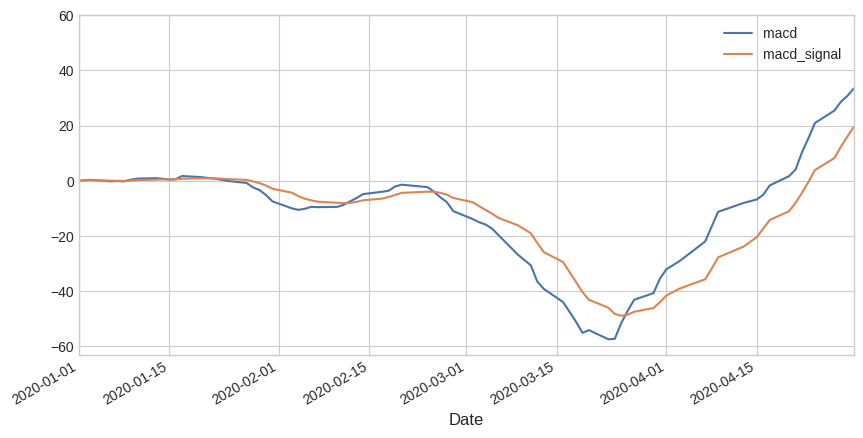

(18262.0, 18382.0)

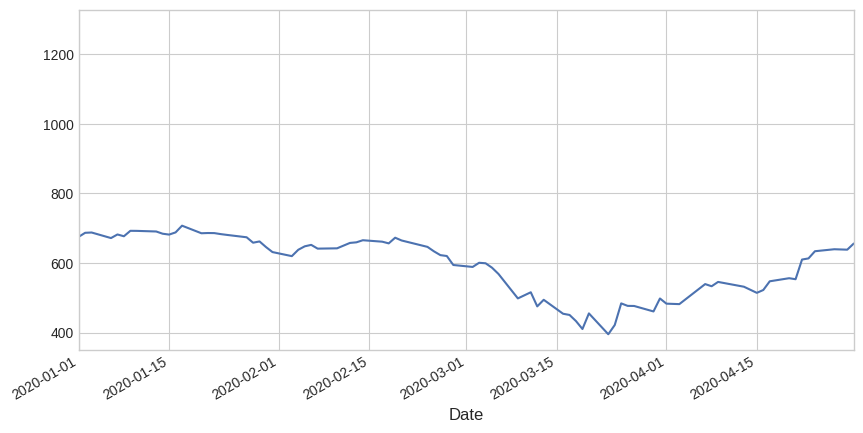

In [12]:
df_indicators["macd"].plot()
df_indicators["macd_signal"].plot()
# df_indicators["macd_histogram"].plot()
# df_indicators["rsi"].plot()
# plt.axhline(y=30)
# plt.axhline(y=70)
plt.xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-04-30"))
plt.legend()
plt.show()

df_indicators["Close"].plot()
plt.xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-04-30"))

### Devise The Trading startegy / Generate Signals for long / short / flat calls
- Suggested by **Parth Parmar** on 03.11.2025
- Combines multiple technical indicators to generate **buy**, **sell**, or **flat** signals.  
- Uses volume, momentum (RSI), trend (SMA crossover), and MACD-based confirmations to decide positions.


#### **Conditions**

- **C1 (Volume Confirmation):**  
  Daily trading volume crosses above its 7-day simple moving average (SMA).  
  → Participation only when market activity is high.

- **C2 (RSI Momentum):**  
  RSI crosses above 30 but remains below 70.  
  → Filters out oversold (<30) and overbought (>70) regimes.

- **C3 (Trend Confirmation):**  
  A *Golden Cross* occurs — 50-day SMA crosses above the 200-day SMA.  
  → Indicates a transition to a long-term bullish trend.

- **C4 (MACD Confirmation):**  
  MACD line crosses above the signal line.  
  → Confirms short-term bullish momentum from MACD dynamics.

---

#### **Trading Rules**

- **Trade only when C1 (volume condition) is satisfied.**

| Signal Type | Conditions Met |
|--------------|----------------|
| **Buy (1)**  | C1 **and** at least two of (C2–C4) are satisfied |
| **Sell (-1)**| C1 **and** none of (C2–C4) are satisfied |
| **Flat (0)** | C1 not satisfied **or** exactly one of (C2–C4) is satisfied **or** RSI < 30 |

---

Each day, the strategy evaluates these conditions to determine the position:
- `1` → **Go Long (Buy)**
- `-1` → **Go Short (Sell)**
- `0` → **Stay Flat**


In [14]:
def generate_trading_signals(df_indicators):
    df = df_indicators.copy()

    # Condition C1: Volume crosses above its 7-day SMA
    df['C1'] = (df['Volume'] > df['volume_sma'])

    # Condition C2: RSI between 30 and 70, and crossing above 30
    df['C2'] = ((df['rsi'] > 30) & (df['rsi'] < 70) & (df['rsi'].shift(1) <= 30))

    # Condition C3: Golden crossover (50-SMA crosses above 200-SMA)
    df['C3'] = ((df['sma_50'] > df['sma_200']) & (df['sma_50'].shift(1) <= df['sma_200'].shift(1)))

    # Condition C4: MACD signal line crossing MACD line from above
    df['C4'] = ((df['macd'] > df['macd_signal']) & (df['macd'].shift(1) <= df['macd_signal'].shift(1)))

    # Generate trading signals
    df['signal'] = 0  # default: flat

    # Only trade when C1 is satisfied
    trade_condition = df['C1']

    # Count how many of C2–C4 are true
    df['num_conditions'] = df[['C2', 'C3', 'C4']].sum(axis=1)

    # Buy signal: C1 true AND at least two of (C2–C4) true
    buy_condition = trade_condition & (df['num_conditions'] >= 2)
    df.loc[buy_condition, 'signal'] = 1

    # Sell signal: C1 true AND none of (C2–C4) true
    sell_condition = trade_condition & (df['num_conditions'] == 0)
    df.loc[sell_condition, 'signal'] = -1

    # Flat signal: C1 false OR (C1 true but only one of C2–C4 true) OR RSI < 30
    flat_condition = ~trade_condition | (df['num_conditions'] == 1) | (df['rsi'] < 30)
    df.loc[flat_condition, 'signal'] = 0

    df['crossover'] = 0  # Track crossover events
    df.loc[buy_condition | sell_condition, 'crossover'] = 1  # 1 if crossover happens, 0 otherwise

    return df

df_signals = generate_trading_signals(df_indicators)